# Challenge : predict conversions 🏆🏆

This is the template that shows the different steps of the challenge. In this notebook, all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the preprocessing/training steps to get the model with the best f1-score ! May the force be with you 🧨🧨  

**For a detailed description of this project, please refer to *02-Conversion_rate_challenge.ipynb*.**

# Import libraries

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=[
        "#4B9AC7",
        "#4BE8E0",
        "#9DD4F3",
        "#97FBF6",
        "#2A7FAF",
        "#23B1AB",
        "#0E3449",
        "#015955",
    ]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg"  # to be replaced by "iframe" if working on JULIE

# Read file with labels

In [39]:
df = pd.read_csv("df.csv")

# Preprocessing

## preprocessing pandas

Detect outlyers age and total_pages_visited. We apply 3 sigma rule : to 1 sigma from mean, 60% of dataset is included in area. To 2 sigma, 95% and to 3 sigma, 99%. Then we drop entries outside 3 sigma from the mean.

In [40]:
string = ['country', 'source']

for col in string:
    df[col] = df[col].str.lower()

### drop outlyers

In [41]:
upper_bound = 80
mask = df['age'] < upper_bound
mask

0         True
1         True
2         True
3         True
4         True
          ... 
284575    True
284576    True
284577    True
284578    True
284579    True
Name: age, Length: 284580, dtype: bool

In [42]:
df = df.loc[mask, :]
print("Done. Number of lines remaining : ", df.shape[0])
print(df.head())

Done. Number of lines remaining :  284578
   country  age  new_user  source  total_pages_visited  converted
0    china   22         1  direct                    2          0
1       uk   21         1     ads                    3          0
2  germany   20         0     seo                   14          1
3       us   23         1     seo                    3          0
4       us   28         1  direct                    3          0


In [43]:
df.describe(include='all')

,country,age,new_user,source,total_pages_visited,converted
count,284578,284578.000000,284578.000000,284578,284578.000000,284578.000000
unique,4,NaN,NaN,3,NaN,NaN
top,us,NaN,NaN,seo,NaN,NaN
freq,160124,NaN,NaN,139476,NaN,NaN
mean,NaN,30.563596,0.685457,NaN,4.873198,0.032251
std,NaN,8.263627,0.464334,NaN,3.341939,0.176667
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000


## preprocessing en sklearn

### Multivariate logistic regression

In [44]:
df2 = df.copy()

#### Separate target variable Y from features X

In [45]:
# Separate target variable Y from features X

print("Separating labels from features...")
target = 'converted'

y = df.loc[:, target]# or df.iloc[:, -1] # or  df.loc[:, df.columns == target]
X = df.drop(target, axis=1) # or df.iloc[:, 0:-1]  # All columns are kept, except the target
# or df.loc[:, df.columns != target]
print("...Done.")

print("y : ")
print(y.head())
print()
print("X : ")
print(X.head())

Separating labels from features...
...Done.
y : 
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

X : 
   country  age  new_user  source  total_pages_visited
0    china   22         1  direct                    2
1       uk   21         1     ads                    3
2  germany   20         0     seo                   14
3       us   23         1     seo                    3
4       us   28         1  direct                    3


In [46]:
'''# Automatically detect names of numeric/categorical columns
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Found numeric features ", numeric_features)
print("Found categorical features ", categorical_features)'''

'# Automatically detect names of numeric/categorical columns\nnumeric_features = X.select_dtypes(include="number").columns.tolist()\ncategorical_features = X.select_dtypes(exclude="number").columns.tolist()\n\nprint("Found numeric features ", numeric_features)\nprint("Found categorical features ", categorical_features)'

In [47]:
numeric_features = ['age', 'total_pages_visited']
categorical_features = ['country', 'source', 'new_user']

print("Found numeric features ", numeric_features)
print("Found categorical features ", categorical_features)

Found numeric features  ['age', 'total_pages_visited']
Found categorical features  ['country', 'source', 'new_user']


#### divide dataset train set & test set 

We apply different transformations to the features, depending on their types. Numeric columns will be standardized whereas categorical columns will be one-hot-encoded. As regards missing values imputation, it can apply to every column, but different rules may be used. 

In [48]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
# WARNING : don't forget stratify=Y for classification problems
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



We don't use simple imputer because we don't have any missing values. num_imputer = SimpleImputer(strategy="median")

We normalize numeric colomns to scale them down.

#### pipelines

In [49]:
print("Preprocessing X_train...")
print(X_train.head())
print()

# categoric

cat_transformer = Pipeline(steps=[
    ('catEncoder', OneHotEncoder(drop='first'))
])
# numerical

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

Preprocessing X_train...
        country  age  new_user  source  total_pages_visited
14322        uk   37         1     ads                    3
251570       uk   27         0     seo                   13
53008        us   26         0  direct                    4
121373       us   24         0     seo                    1
151639  germany   33         0     ads                    2



In [50]:
#### pipeline global
print("Encoding categorical features and standardizing numerical features...")

preprocessor = ColumnTransformer(transformers=[
    ('cat_transformer', cat_transformer, categorical_features),
    ('num_transformer', num_transformer, numeric_features)
])

# Preprocessings on train set
print("Preprocessing sur le train set...")
X_train = preprocessor.fit_transform(X_train)
print('...Terminé.')
X_train[0:5] # MUST use this syntax because X_train is a numpy array and not a pandas DataFrame anymore
print()


Encoding categorical features and standardizing numerical features...
Preprocessing sur le train set...
...Terminé.



Nous n'utilisons pas labelEncoder sur y_test car les labels sont déjà convertis sur converted

#### Test pipeline

In [51]:
# Preprocessings sur le test train
print("Preprocessing on test set...")
X_test = preprocessor.transform(X_test) # Don't fit again !! The test set is used for validating decisions
# we made based on the training set, therefore we can only apply transformations that were parametered using the training set.
# Otherwise this creates what is called a leak from the test set which will introduce a bias in all your results.
print('...Done.')
X_test[:5, :] # MUST use this syntax because X_test is a numpy array and not a pandas DataFrame anymore

Preprocessing on test set...
...Done.


array([[ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.77869487, -0.86022495],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  1.62497205, -0.56105227],
       [ 0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        , -0.79296275,  3.32819262],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.41600465, -0.56105227],
       [ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        , -0.79296275,  0.0372931 ]])

#### Train model

In [52]:

from sklearn.linear_model import LogisticRegression

print("Train model...")
classifier = LogisticRegression(random_state=42) # 
classifier.fit(X_train, y_train)
print("...Done.")

Train model...
...Done.


#### Predictions

In [53]:
# Predictions on training set
print("Predictions on training set...")
y_train_pred = classifier.predict(X_train)
print("...Done.")
print(y_train_pred)
print()

Predictions on training set...
...Done.
[0 1 0 ... 0 0 0]



In [54]:
# Predictions on training set
print("Predictions on training set...")
y_train_pred = classifier.predict(X_train)
print("...Done.")
print(y_train_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on training set...")
y_train_proba = classifier.predict_proba(X_train)
print("...Done.")
print(y_train_proba)
print()

Predictions on training set...
...Done.
[0 1 0 ... 0 0 0]

Probabilities on training set...
...Done.
[[9.99875857e-01 1.24142519e-04]
 [2.55137451e-01 7.44862549e-01]
 [9.98038604e-01 1.96139584e-03]
 ...
 [9.99995582e-01 4.41838052e-06]
 [9.99965204e-01 3.47961470e-05]
 [9.95405447e-01 4.59455276e-03]]



In [55]:
# Predictions on test set
print("Predictions on test set...")
y_test_pred = classifier.predict(X_test)
print("...Done.")
print(y_test_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on test set...")
y_test_proba = classifier.predict_proba(X_test)
print("...Done.")
print(y_test_proba)
print()

Predictions on test set...
...Done.
[0 0 1 ... 0 0 0]

Probabilities on test set...
...Done.
[[9.99998181e-01 1.81880721e-06]
 [9.99997156e-01 2.84437232e-06]
 [3.36057651e-02 9.66394235e-01]
 ...
 [9.95740310e-01 4.25968987e-03]
 [9.99553926e-01 4.46073651e-04]
 [9.99154872e-01 8.45127632e-04]]



#### Performance evaluation

In [56]:
# Print scores
print("accuracy on training set : ", accuracy_score(y_train, y_train_pred))
print("accuracy on test set : ", accuracy_score(y_test, y_test_pred))
print()

print("f1-score on training set : ", f1_score(y_train, y_train_pred))
print("f1-score on test set : ", f1_score(y_test, y_test_pred))
print()

accuracy on training set :  0.9862691182542541
accuracy on test set :  0.9861374657389838

f1-score on training set :  0.7643244873341375
f1-score on test set :  0.7590839694656488



Attention, le jeu de données est très déséquilibré. Accuracy score n'est pas significatif. # Here, the f1-score will be used to assess the performances on the leaderboard.

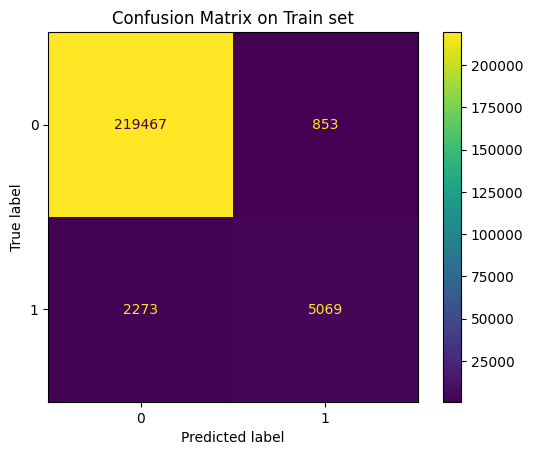

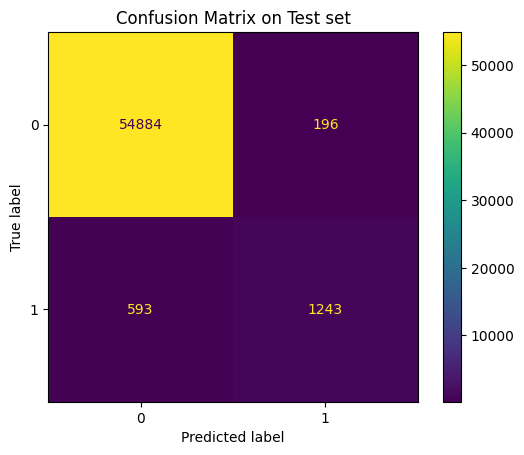

In [57]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    classifier, X_train, y_train, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    classifier, X_test, y_test, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

**Our baseline model reaches a f1-score of 76%.

TODO recall et précision

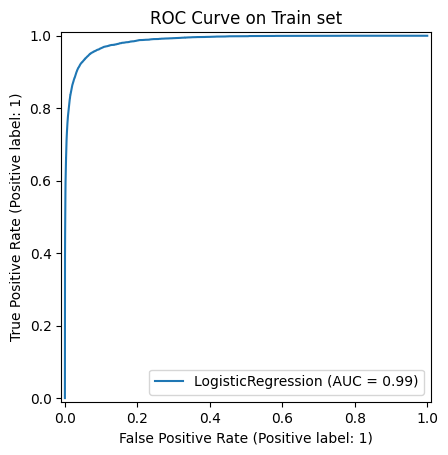

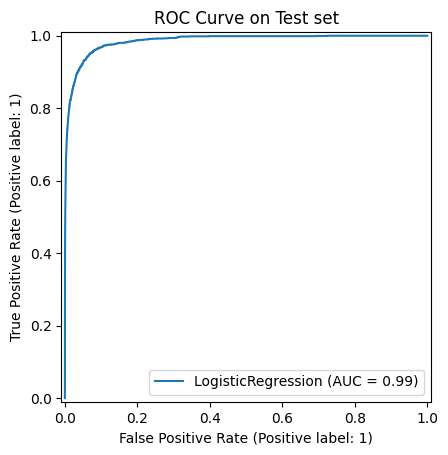

In [58]:
# Visualize ROC curves
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="ROC Curve on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(
    classifier, X_train, y_train, ax=ax
)  # RocCurveDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="ROC Curve on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(
    classifier, X_test, y_test, ax=ax
)  # RocCurveDisplay from sklearn
plt.show()


La courbe est trop optimiste. La PR AUC est plus réaliste. 

# Cross-validation

In [59]:
print("Separating labels from features...")
target = 'converted'

y = df2.loc[:, target]# or df.iloc[:, -1] # or  df.loc[:, df.columns == target]
X = df2.drop(target, axis=1) # or df.iloc[:, 0:-1]  # All columns are kept, except the target
# or df.loc[:, df.columns != target]
print("...Done.")

print("y : ")
print(y.head())
print()
print("X : ")
print(X.head())
numeric_features = ['age', 'total_pages_visited']
categorical_features = ['country', 'source', 'new_user']

print("Found numeric features ", numeric_features)
print("Found categorical features ", categorical_features)
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
# WARNING : don't forget stratify=Y for classification problems
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("...Done.")
print()

print("Preprocessing X_train...")
print(X_train.head())
print()

# categoric

cat_transformer = Pipeline(steps=[
    ('catEncoder', OneHotEncoder(drop='first'))
])
# numerical

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
#### pipeline global
print("Encoding categorical features and standardizing numerical features...")

preprocessor = ColumnTransformer(transformers=[
    ('cat_transformer', cat_transformer, categorical_features),
    ('num_transformer', num_transformer, numeric_features)
])

# # Preprocessings on train set
# print("Preprocessing sur le train set...")
# X_train = preprocessor.transform(X_train) # transform. Pas fit_transform pour éviter la fuite de données
# print('...Terminé.')
# X_train[0:5] # MUST use this syntax because X_train is a numpy array and not a pandas DataFrame anymore
# print()


Separating labels from features...
...Done.
y : 
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

X : 
   country  age  new_user  source  total_pages_visited
0    china   22         1  direct                    2
1       uk   21         1     ads                    3
2  germany   20         0     seo                   14
3       us   23         1     seo                    3
4       us   28         1  direct                    3
Found numeric features  ['age', 'total_pages_visited']
Found categorical features  ['country', 'source', 'new_user']
Dividing into train and test sets...
...Done.

Preprocessing X_train...
        country  age  new_user  source  total_pages_visited
14322        uk   37         1     ads                    3
251570       uk   27         0     seo                   13
53008        us   26         0  direct                    4
121373       us   24         0     seo                    1
151639  germany   33         0     ads                    2



In [60]:
# # Perform 10-fold cross-validation
# print("5-fold cross-validation...")
# scores = cross_val_score(classifier, X_train, y_train, cv=(10))
# print('The cross-validated accuracy is : ', scores.mean())
# print('The standard deviation is : ', scores.std())

In [61]:
### training with hyperparameter optimization
# # Perform grid search
print("Grid search...")
classifier = DecisionTreeClassifier(random_state=42)

pipeline_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier()),
])

# Grid of values to be tested
params = {
    "model__max_depth": [4, 6, 8, 10, 15],
    "model__min_samples_leaf": [1, 2, 5, 10, 50, 100],
    "model__min_samples_split": [2, 10, 20, 100, 250],
}
gridsearch = GridSearchCV(
    pipeline_dt, param_grid=params, cv=3, error_score='raise', scoring='f1', n_jobs=-1
)  # cv : the number of folds to be used for CV
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best F1 score : ", gridsearch.best_score_)

Grid search...
...Done.
Best hyperparameters :  {'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best F1 score :  0.7476791252371061


In [71]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score, average_precision_score
from sklearn.model_selection import cross_val_predict


### training with hyperparameter optimization
# # Perform grid search
print("Grid search...")
classifier = DecisionTreeClassifier(random_state=42)

pipeline_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", classifier),
])

# Grid of values to be tested
params = {
    "model__max_depth": [4, 6, 7, 8, 9, 10, 15],
    "model__min_samples_leaf": [1, 2, 5, 10, 23, 25],
    "model__min_samples_split": [2, 10, 25, 50, 75, 90, 93, 95, 97, 100, 105, 110],
}
gridsearch = GridSearchCV(
    pipeline_dt, param_grid=params, cv=3, error_score='raise', scoring={'f1':'f1', 'pr_auc':'average_precision'}, refit='pr_auc', n_jobs=-1
)  # cv : the number of folds to be used for CV
gridsearch.fit(X_train, y_train)

best_model = gridsearch.best_estimator_
y_proba_cv = cross_val_predict(best_model, X_train, y_train, cv=3, method="predict_proba")[:, 1]

# Étape 1 : seuil choisi sur le train (y_proba_cv = probabilités out-of-fold)
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train, (y_proba_cv >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

# Étape 2 : application au test
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print('Best PR AUC :', gridsearch.best_score_)
# print("Best validation accuracy : ", gridsearch.best_score_)
print("Best F1 score (mean) : ", gridsearch.cv_results_["mean_test_f1"][gridsearch.best_index_])
print("recall test :", recall_score(y_test, y_pred_test))
print("précision :", precision_score(y_test, y_pred_test))
print("Seuil :", best_threshold)

Grid search...
...Done.
Best hyperparameters :  {'model__max_depth': 8, 'model__min_samples_leaf': 23, 'model__min_samples_split': 100}
Best PR AUC : 0.8190365818117821
Best F1 score (mean) :  0.7481653502210671
recall test : 0.721677559912854
précision : 0.7929383602633154
Seuil : 0.4000000000000001


Best hyperparameters :  {'model__max_depth': 8, 'model__min_samples_leaf': 25, 'model__min_samples_split': 110}
Best PR AUC : 0.8185123757897136
Best F1 score (mean) :  0.7486836580037464

Best hyperparameters :  {'model__max_depth': 8, 'model__min_samples_leaf': 23, 'model__min_samples_split': 100}
Best PR AUC : 0.8190365818117821
Best F1 score (mean) :  0.7481653502210671

In [72]:
# Predictions on test set
print("Predictions on test set...")
y_test_pred = gridsearch.predict(X_test)
print("...Done.")
print(y_test_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on test set...")
y_test_proba = gridsearch.predict_proba(X_test)
print("...Done.")
print(y_test_proba)
print()

Predictions on test set...
...Done.
[0 0 1 ... 0 0 0]

Probabilities on test set...
...Done.
[[9.99928690e-01 7.13103999e-05]
 [9.99928690e-01 7.13103999e-05]
 [1.06382979e-02 9.89361702e-01]
 ...
 [9.97367761e-01 2.63223866e-03]
 [9.99082821e-01 9.17178758e-04]
 [9.99812058e-01 1.87941663e-04]]



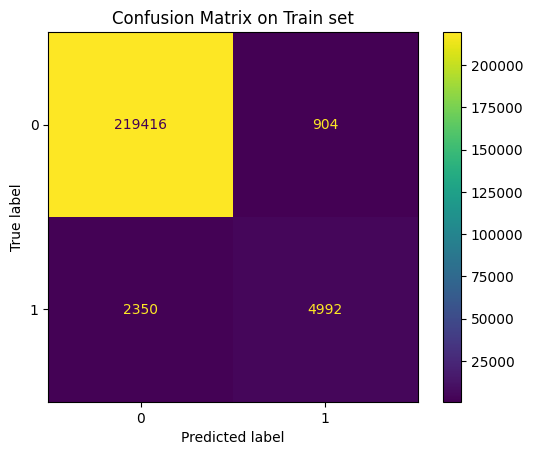

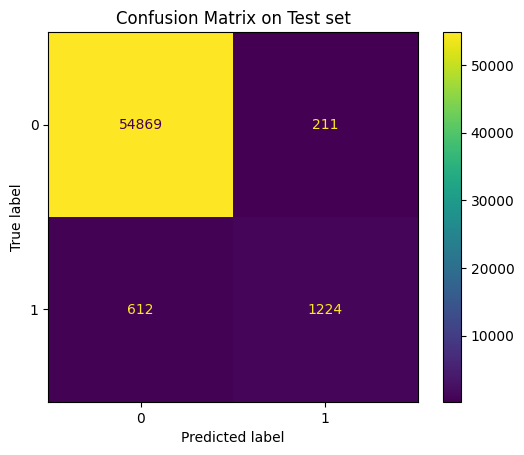

In [73]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    gridsearch, X_train, y_train, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    gridsearch, X_test, y_test, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()


In [75]:
print('Coefficients of the Logistic regression model:')
DecisionTreeClassifier.coef_

Coefficients of the Logistic regression model:


AttributeError: type object 'DecisionTreeClassifier' has no attribute 'coef_'

In [76]:
# Create a pandas DataFrame with the model's coefficients
X = pd.DataFrame(
    X_train,   # matrice encodée (8 colonnes)
    columns=preprocessor.get_feature_names_out()
)
coefs = pd.DataFrame(index = X.columns, data = classifier.coef_.transpose(), columns=['coef']).sort_values("coef", ascending=False)
coefs

NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

X.columns donne les 5 colonnes brutes, mais coef_ a 8 valeurs (après encodage). get_feature_names_out() donne les 8 noms dans le bon ordre.
columns=['?'] : contient les numéros de colonne. Ces informations vont me permettre d'ajuster les hyperparamètres.